In [1]:
import sys
sys.path.append("/project/src")

In [2]:
from coxmodel import CoxPH
from lifelines.utils import concordance_index
from lifelines.exceptions import ConvergenceWarning
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import joblib
import warnings
from scipy.stats import randint, uniform
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import uniform, loguniform
from sklearn.model_selection import validation_curve
from sklearn.pipeline import Pipeline

from preprocessing import (
    split_features_target,
    build_survival_target,
    low_missingness_complete_case_analysis,
    concat_features_target,
    decode_preprocessed_feature_name,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
    BaseDatasetPreprocessor,
)

# Read datasets

In [3]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    train_df_csv = "/content/drive/MyDrive/bachelor/nacc_train_reduced.csv"
else:
    train_df_csv = "./data/nacc_train_reduced.csv"

In [4]:
train_df = pd.read_csv(train_df_csv, delimiter=',')

In [5]:
train_df.shape

(6499, 141)

## Compute X and y and calculate weights

In [6]:
train_X, train_y = split_features_target(train_df)

# Initialize wandb

In [7]:
features_num = train_df.shape[1]
n_samples = train_df.shape[0]

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="semariik",
    # Set the wandb project where this run will be logged.
    project="survival-analysis-mci",
)

wandb.define_metric("cox/*", step_metric="cox/lambda")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


# Parameters and constents definition

In [8]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [9]:
duration_col = "TIME"
event_col    = "EVENT_MCI"
lambdas      = np.logspace(-1, 2, 50)

In [10]:
param_distributions = {
    'model__penalizer': loguniform(0.1, 100),
    'model__l1_ratio':  uniform(0, 1),
}

In [11]:
cox_tunning_pipeline = Pipeline([
  ('preprocessor', BaseDatasetPreprocessor()),
  ("model", CoxPH(duration_col=SURVIVAL_TIME_COL, event_col=SURVIVAL_EVENT_COL, compute_weights=True))
])

# Cox model tunning

## Tune parameters with GridSearchCV

In [12]:
def cox_concordance_scorer(estimator, X, y):
    # with warnings.catch_warnings(record=True) as caught:
    #     warnings.simplefilter("always", ConvergenceWarning)
    #     score = estimator.score(X, y)

    # for w in caught:
    #     msg = str(w.message)
    #     if "Newton-Raphson failed" in msg or "suspiciously close to 0" in msg:
    #         return 0.5

    score = estimator.score(X, y)

    return score

In [13]:
cv_splits = list(cv.split(train_X, train_y[event_col].astype(int)))

random_search = RandomizedSearchCV(
    estimator=cox_tunning_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv_splits,
    scoring=cox_concordance_scorer,
    refit=True,
    error_score=0.5
)

In [14]:
random_search.fit(train_X, train_y)

Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns

Fitting CoxPH with parameters: penalizer=43.85299561012103, l1_ratio=0.34042828438182704, compute_weights=True
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns

Fitting CoxPH with parameters: penalizer=43.85299561012103, l1_ratio=0.34042828438182704, compute_weights=True
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns

Fitting CoxPH with parameters: penalizer=43.85299561012103, 

/usr/local/lib/python3.13/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns

Fitting CoxPH with parameters: penalizer=0.14811378116581192, l1_ratio=0.9841283229000438, compute_weights=True
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns

Fitting CoxPH with parameters: penalizer=2.7325476499875365, l1_ratio=0.831083580921589, compute_weights=True
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating mi

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', CoxPH())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__l1_ratio': <scipy.stats....xffff19449310>, 'model__penalizer': <scipy.stats....xffff193ee660>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",<function cox...xffff192c8c20>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

## Asses overfitting and underfitting and select optimal lambda

Create error curves for cross validation and train. Check that optimally selected parameters are the optimal point,w here no overfit no undefit. Reselect better lambda, in case of need by graph

In [15]:
# train_errors = []
# val_errors   = []
# val_stds     = []

# for penalizer in lambdas:
#     fold_train = []
#     fold_val   = []

#     for train_idx, val_idx in cv_splits:
#         X_train_fold = train_X.iloc[train_idx]
#         y_train_fold = train_y[train_idx]
#         X_val_fold   = train_X.iloc[val_idx]
#         y_val_fold   = train_y[val_idx]

#         model = CoxPH(penalizer=penalizer, l1_ratio=0.0, duration_col=duration_col, event_col=event_col, compute_weights=True)
#         model.fit(X_train_fold, y_train_fold)

#         c_index_train = model.score(X_train_fold, y_train_fold)
#         c_index_val   = model.score(X_val_fold,   y_val_fold)

#         fold_train.append(1 - c_index_train)
#         fold_val.append(1 - c_index_val)

#     train_errors.append(np.mean(fold_train))
#     val_errors.append(np.mean(fold_val))
#     val_stds.append(np.std(fold_val) / np.sqrt(5))

#     wandb.log({
#         "cox/lambda":      penalizer,
#         "cox/log_lambda":  np.log(penalizer),
#         "cox/train_error": train_errors[-1],
#         "cox/val_error":   val_errors[-1],
#         "cox/gap":         val_errors[-1] - train_errors[-1],
#     })

In [16]:
random_search.best_params_

{'model__l1_ratio': np.float64(0.02724747304501096),
 'model__penalizer': np.float64(0.3926694832730409)}

In [17]:
best_model_fit_assesment_pipeline = Pipeline([
  ('preprocessor', BaseDatasetPreprocessor()),
  ("model", CoxPH(duration_col=SURVIVAL_TIME_COL, event_col=SURVIVAL_EVENT_COL, compute_weights=True, penalizer=random_search.best_params_['model__penalizer'], l1_ratio=random_search.best_params_['model__l1_ratio']))
])

In [18]:
train_scores, val_scores = validation_curve(
    estimator=best_model_fit_assesment_pipeline,
    X=train_X,
    y=train_y,
    param_name='model__penalizer',
    param_range=lambdas,
    cv=cv_splits,
    scoring=cox_concordance_scorer,
    error_score=0.5,
)

train_errors = 1 - np.mean(train_scores, axis=1)
val_errors   = 1 - np.mean(val_scores,   axis=1)
val_stds     = np.std(val_scores, axis=1) / np.sqrt(3)

Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns

Fitting CoxPH with parameters: penalizer=0.1, l1_ratio=0.02724747304501096, compute_weights=True
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns

Fitting CoxPH with parameters: penalizer=0.11513953993264472, l1_ratio=0.02724747304501096, compute_weights=True
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented t

In [19]:
for i, penalizer in enumerate(lambdas):
    wandb.log({
        "cox/lambda":      penalizer,
        "cox/train_error": train_errors[i],
        "cox/val_error":   val_errors[i],
        "cox/gap":         val_errors[i] - train_errors[i],
    })

In [26]:
lambdas

array([  0.1       ,   0.11513954,   0.13257114,   0.1526418 ,
         0.17575106,   0.20235896,   0.23299518,   0.26826958,
         0.30888436,   0.35564803,   0.40949151,   0.47148664,
         0.54286754,   0.62505519,   0.71968567,   0.82864277,
         0.95409548,   1.09854114,   1.26485522,   1.45634848,
         1.67683294,   1.93069773,   2.22299648,   2.55954792,
         2.9470517 ,   3.39322177,   3.90693994,   4.49843267,
         5.17947468,   5.96362332,   6.86648845,   7.90604321,
         9.10298178,  10.48113134,  12.06792641,  13.89495494,
        15.9985872 ,  18.42069969,  21.20950888,  24.42053095,
        28.11768698,  32.37457543,  37.2759372 ,  42.9193426 ,
        49.41713361,  56.89866029,  65.51285569,  75.43120063,
        86.85113738, 100.        ])

In [20]:
train_errors

array([0.21123155, 0.21152393, 0.21182218, 0.21226501, 0.21281055,
       0.21341815, 0.21408803, 0.21480753, 0.21560018, 0.21645785,
       0.2173269 , 0.21815141, 0.21897333, 0.21975433, 0.22062445,
       0.22143422, 0.22237958, 0.22333477, 0.2244197 , 0.22607814,
       0.22866544, 0.23163733, 0.23355991, 0.23539534, 0.23724016,
       0.23879506, 0.24064047, 0.24312803, 0.24540383, 0.24921111,
       0.3115507 , 0.27575234, 0.25097747, 0.2525725 , 0.25346967,
       0.25408343, 0.25449733, 0.25478855, 0.25499108, 0.25513084,
       0.25522244, 0.25529488, 0.25535865, 0.25540387, 0.25544046,
       0.25546396, 0.25547988, 0.25549341, 0.25550501, 0.2555138 ])

In [21]:
val_errors

array([0.2392758 , 0.23868034, 0.23811856, 0.23745575, 0.23677854,
       0.23619931, 0.23560914, 0.23510721, 0.23464679, 0.23429109,
       0.23393196, 0.23350011, 0.23333312, 0.23332702, 0.23347336,
       0.23365863, 0.23378786, 0.23388215, 0.23447909, 0.23540989,
       0.2368359 , 0.23848502, 0.23951817, 0.24009254, 0.24084204,
       0.24176747, 0.24280536, 0.24434987, 0.24791364, 0.2531711 ,
       0.31356303, 0.2861903 , 0.258598  , 0.2602545 , 0.26123536,
       0.2618233 , 0.26226427, 0.26253109, 0.2627114 , 0.26286907,
       0.26294993, 0.26301356, 0.26308668, 0.2631367 , 0.26315511,
       0.26316635, 0.26317529, 0.26318653, 0.26319604, 0.26320376])

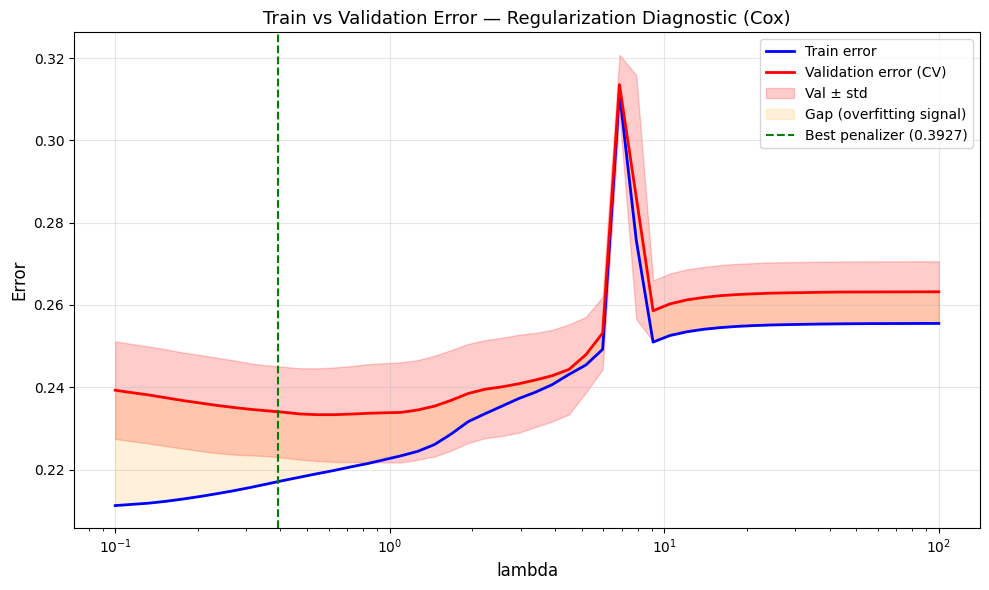

In [28]:
best_penalizer = random_search.best_params_['model__penalizer']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lambdas, train_errors, color="blue", linewidth=2, label="Train error")
ax.plot(lambdas, val_errors,   color="red",  linewidth=2, label="Validation error (CV)")

ax.fill_between(lambdas, val_errors - val_stds, val_errors + val_stds,
                alpha=0.2, color="red", label="Val ± std")
ax.fill_between(lambdas, train_errors, val_errors,
                alpha=0.15, color="orange", label="Gap (overfitting signal)")

ax.axvline(x=best_penalizer, color="green", linestyle="--", linewidth=1.5,
           label=f"Best penalizer ({best_penalizer:.4f})")

ax.set_xscale("log")
ax.set_xlabel("lambda", fontsize=12)
ax.set_ylabel("Error", fontsize=12)
ax.set_title("Train vs Validation Error — Regularization Diagnostic (Cox)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cox_lambda_curves.png", dpi=150, bbox_inches="tight")
plt.show()

3500 slov

In [23]:
cox_best_params = random_search.best_params_
cox_best_params

{'model__l1_ratio': np.float64(0.02724747304501096),
 'model__penalizer': np.float64(0.3926694832730409)}

In [29]:
cv_cindex = random_search.best_score_
cv_cindex

np.float64(0.7659751008257678)

In [32]:
cv_cindex_std = random_search.cv_results_['std_test_score'][random_search.best_index_] 
cv_cindex_std

np.float64(0.01910917297655706)

In [ ]:
wandb.log({"best_parameters": cox_best_params})
joblib.dump(cox_best_params, "joblib-storage/cox_best_params.joblib")
joblib.dump(random_search.best_estimator_, "joblib-storage/cox_best_pipeline.joblib")
joblib.dump(cv_cindex, "joblib-storage/cox_best_cv_cindex.joblib")
joblib.dump(cv_cindex_std, "joblib-storage/cox_best_cv_cindex_std.joblib")
wandb.finish()

['joblib-storage/cox_best_cv_cindex_std.joblib']